# Importance value Index

## Foreword
According to Curtis & McIntosh ([1951](https://doi.org/10.2307/1931725)) , the Standard IVI is a composite quantitative measure of a species' "relative importance" within a community, calculated as the sum of its relative density, frequency, and dominance to provide a single, non-biased value of ecological success.

It is applied to tropical forest ecosystem structure assessment because raw abundance alone is misleading in high-diversity systems; the IVI allows researchers to identify "hyperdominant" species that may be few in number but possess massive biomass (high basal area) or wide spatial distribution across complex landscapes.

In this case, we calculate the IVI for a tropical premontane wet forest located in the Pacific Region in Colombia to establish which are the most important forest tree species in our ecosystem.


## 1. Import libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inventory_data import load_inventory

## 2. Import data

Here we load the dataset through a function that was previously defined in [inventory_data.py](https://github.com/miguelif92/IVI-ForstEcol/blob/main/notebook/inventory_data.py).

In [19]:
# Load an Excel file
df = df = load_inventory()

## 3. Data tidying

Data are divided in lines, which correspond to the different forest zones.

In [20]:
#Data are divided according to line number
line1 = df[df["Line Number"] == 1]
line2 = df[df["Line Number"] == 2]
line3 = df[df["Line Number"] == 3]
line4 = df[df["Line Number"] == 4]
line5 = df[df["Line Number"] == 5]
line6 = df[df["Line Number"] == 6]
line7 = df[df["Line Number"] == 7]

## 4. Importance Value Index (IVI)

IVI has three components: Dominance, frequency and density (abundance), which will be calculcated separately. For a better understanding, Line 1 will be used as an example of how could we calculate the different IVI components.

In [21]:
# Here we just create the dictionaries to be used in the plot
dict_ivi = {
    "Fr": "Relative Frequency",
    "Dr": "Relative Dominance", 
    "Ab": "Relative Abundance",
}

color_ivi = {
    "Fr": "#1f77b4",   
    "Dr": "#be2f2f",
    "Ab": "#58dd58",
    }

### 4.1 Frequency

Frequency is defined as the existance of a certain tree species in a sample plot. Relative frequency is calculated and expressed in percetage values. First, we count the total unique tree species' values as well as the plot's count.

$$ F_{i} = \frac{p_{i}}{P} * 100 $$

$$ Fr = \frac{F_{i}}{\sum{F_{i}}} * 100 $$

Where:

$\large p_{i}:$ Number of plots in which *i* tree species is found.

$\large P: $ Total number of plots.

$\large F_{i}: $ Absolute frequency for each *i* tree species.

$\large Fr: $ Relative frequency [%].

In [22]:
# Create the frequency table for line 1 - count of unique Plots per Scientific name
fr1 = line1.pivot_table(
    index='Scientific name',      # Group by Scientific name
    values='Plot',     # Count unique plots
    aggfunc='nunique'       # Count unique values in each group
)

fr1 = fr1[fr1['Plot'] > 0]

fr1.sort_values(by='Plot', ascending=False)

# Count unique plots in line1
pl1 = line1['Plot'].nunique()

print("The number of unique plots in line 1 is:", pl1)

The number of unique plots in line 1 is: 12


C:\Users\migue\AppData\Local\Temp\ipykernel_21220\4001647843.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fr1 = line1.pivot_table(


Now we calculate the absolute frequency per tree species and we sum those values to obtain the total absolute frequency. The plot count for each tree species is divided into the total absolute frequency to get the relative frequency. Values are descendantly sorted.

In [23]:
fr1["Freq"] = (fr1["Plot"] / pl1) * 100

fr1.sort_values(by='Freq', ascending=False)

plot1= fr1['Plot'].sum()
print(f"The absolute frequency in line 1 is: {plot1}")

fr1["Fr"] = (fr1["Plot"] / plot1) * 100

fr1.sort_values(by='Fr', ascending=False)

The absolute frequency in line 1 is: 346


,Plot,Freq,Fr
Scientific name,,,
nn,11,91.666667,3.179191
Pouteria sp,11,91.666667,3.179191
Prioria sp,11,91.666667,3.179191
Anacardium excelsum,11,91.666667,3.179191
Pterocarpus officinalis,11,91.666667,3.179191
...,...,...,...
Mabea sp,1,8.333333,0.289017
Maquira sp,1,8.333333,0.289017
Platypodium elegans,1,8.333333,0.289017


According to Raunkiaer's frequency classification ([1934](https://www.scirp.org/reference/referencespapers?referenceid=1567375)), tree species are classified based on absolute frequencies (`Freq` column). 

| Class | Absolute Frequency Range |                                                           Ecological meaning                                                            |
|:-----:|:------------------------:|:---------------------------------------------------------------------------------------------------------------------------------------:|
|   I   |           0-20%          |                   High Diversity/Rare Species: This confirms a high number of species that occur in only a few plots.                   |
|   II  |          21-40%          |             Low Intermediate: A significant drop from Class I, suggesting most species are either very rare or very common.             |
|  III  |          41-60%          | Secondary Dominants: It suggests a group of species that are moderately well-distributed, perhaps due to a specific successional stage. |
|   IV  |         61% – 80%        |                                          Frequent: Species that are common but not ubiquitous.                                          |
|   V   |        81% – 100%        |                                         Constant/Dominants: These species are structural trees.                                         |

In [24]:
dict_freq = {
    "I": "0-20",
    "II": "20-40",
    "III": "40-60",
    "IV": "60-80",
    "V": "80-100",
}

# Classify the trees into diameter classes using 10 cm intervals with roman numerals
fr1["Freq class"] = np.select(
    [(fr1["Freq"] > 0) & (fr1["Freq"] <= 20),
     (fr1["Freq"] > 20) & (fr1["Freq"] <= 40),
     (fr1["Freq"] > 40) & (fr1["Freq"] <= 60),
     (fr1["Freq"] > 60) & (fr1["Freq"] <= 80),
     (fr1["Freq"] > 80) & (fr1["Freq"] <= 100)],
    ["I", "II", "III", "IV", "V"],
    default="Other"
)

fr1 = fr1.astype(
    {
        "Freq class": pd.CategoricalDtype(categories=["I", "II", "III", "IV", "V"], ordered=True),
    }
)

fr1.sort_values(by='Fr', ascending=False)

,Plot,Freq,Fr,Freq class
Scientific name,,,,
nn,11,91.666667,3.179191,V
Pouteria sp,11,91.666667,3.179191,V
Prioria sp,11,91.666667,3.179191,V
Anacardium excelsum,11,91.666667,3.179191,V
Pterocarpus officinalis,11,91.666667,3.179191,V
...,...,...,...,...
Mabea sp,1,8.333333,0.289017,I
Maquira sp,1,8.333333,0.289017,I
Platypodium elegans,1,8.333333,0.289017,I


Once we have classified all of the tree species into the frequency scales, we plot the bar chart with the frequency distribution in which we count how many tree specie lie into each frequency class.

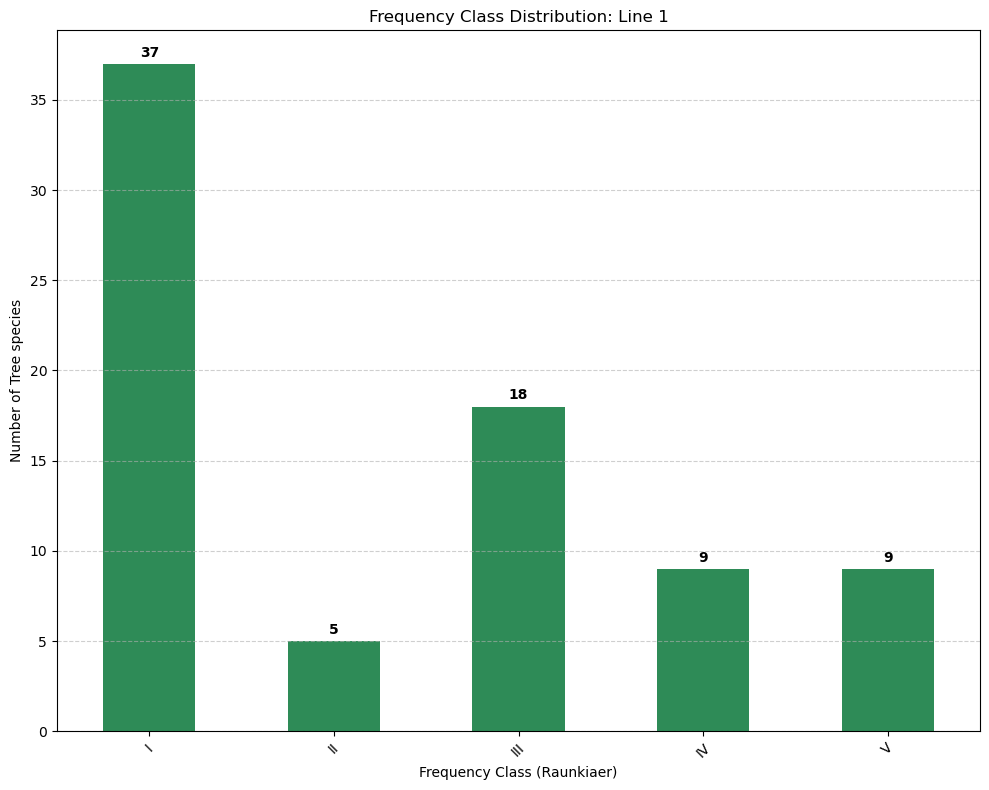

In [25]:
# 1. Create the figure and capture the Axes object (ax)
plt.figure(figsize=(10, 8))
ax = fr1["Freq class"].value_counts().sort_index().plot(kind='bar', color='#2E8B57')
# 2. Add the count labels on top of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight='bold')

# 3. Formatting
plt.xlabel('Frequency Class (Raunkiaer)')
plt.ylabel('Number of Tree species')
plt.title('Frequency Class Distribution: Line 1')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The frequency distribution for Line 1 in this tropical wet premontane forest exhibits a high concentration of species in Class I (37 species), which aligns with Raunkiær’s (1934) observation that stable, high-diversity communities are characterized by a large number of rare or "accidental" species. While the distribution follows the general "inverse J-shape" typical of the Neotropics, the notable "hump" in Class III (18 species) represents a deviation from Raunkiær’s traditional law ($I > II > III > IV < V$), suggesting a group of secondary dominants that may be responding to specific successional stages or topographic transitions in the Colombian Pacific. For the Standard IVI calculation, the 9 species in Class V represent the core structural constants of the stand, possessing the highest Relative Frequency and therefore exerting the greatest influence on the horizontal community structure despite the overall high floristic richness of the site.

### 4.2 Dominance

Dominance is understood as the space or the area that tree species occupy and it is defined as the sum of all horizontal projections for all trees over the terrain level (Melo-Cruz & Vargas-Ríos, 2003). In consequence, basal area is used for calculating dominance for each tree species.

$$ G_{i} = \frac{\pi}{40000}*\sum{d^{2}_{i}} $$

$$ Dr = \frac{G_{i}}{\sum{G_{i}}} * 100 $$

Where:

$\large d_{i}: $ Diameter at breast height in [cm].

$\large G_{i}:$ Total basal area for each *i* tree species.

$\large Dr: $ Relative dominance [%].

In [26]:
# Create the dominance table for line 1
do1 = line1.pivot_table(
    index='Scientific name',      # The categories you want to count
    values='Basal area [m2]',     # The column you are counting
    aggfunc='sum'       # The action: sum the values in each group
)

do1 = do1[do1['Basal area [m2]'] != 0]

do1.sort_values(by='Basal area [m2]', ascending=False)

g1 = do1['Basal area [m2]'].sum()
print(f"The total basal area in line 1 is: {g1} m2")

do1["Dr"] = (do1["Basal area [m2]"] / g1) * 100

do1.sort_values(by='Dr', ascending=False)

The total basal area in line 1 is: 219.7045474648995 m2


C:\Users\migue\AppData\Local\Temp\ipykernel_21220\4168426715.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  do1 = line1.pivot_table(


,Basal area [m2],Dr
Scientific name,,
Prioria copaifera,28.932947,13.169025
Anacardium excelsum,17.725720,8.067981
Pouteria sp,13.427027,6.111402
Ficus glabrata,13.069839,5.948825
Pterocarpus officinalis,12.101714,5.508176
...,...,...
Luehea seemannii,0.030065,0.013685
Ceiba pentandra,0.025288,0.011510
Socratea sp,0.020881,0.009504


### 4.3 Abundance

Absolute abundance is defined as the number of trees per tree species while relative abundance establishes the propertion between absolute abundance and the total number of trees in the sampled area.

$$ Ab = \frac{n_{i}}{\sum{n_{i}}} * 100 $$

Where:

$\large n_{i}: $ Number of trees for each *i* tree species.

$\large Ab: $ Relative abundance [%].

In [27]:
# Abundance per tree species
ab1 = line1.groupby('Scientific name').size().to_frame(name='Abundance')

ab1 = ab1[ab1['Abundance'] > 0]

ab1.sort_values(by='Abundance', ascending=False)

n1 = ab1['Abundance'].sum()

print(f"The total sum is: {n1}")

ab1["Ab"] = (ab1["Abundance"] / n1) * 100

ab1.sort_values(by='Ab', ascending=False)

The total sum is: 2104


C:\Users\migue\AppData\Local\Temp\ipykernel_21220\910720496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ab1 = line1.groupby('Scientific name').size().to_frame(name='Abundance')


,Abundance,Ab
Scientific name,,
Pouteria sp,145,6.891635
Pithecellobium sp.,141,6.701521
Prioria copaifera,136,6.463878
Prioria sp,122,5.798479
Pterocarpus officinalis,112,5.323194
...,...,...
Rheedia madruno,1,0.047529
Luehea seemannii,1,0.047529
Maquira sp,1,0.047529


### 4.4 Summary analysis

IVI is the sum of Relative abundance [*Ab*], relative dominance [*Dr*] and relative frequency [*Fr*] for each *i* tree species. IVI allows to compare the different tree species according to their "ecological weght" inside the forest which is part of the area of interest (Lamprecht, 1990).

Once we have calculated the relative indexes, we sum them for obtaining IVI for each tree species. As a rule, the sum of all IVI values should be equal to 300.

$$ IVI_{i} = Dr_{i} + Fr_{i} + Ab_{i} $$

$$ \sum{IVI_{i}} = 300 $$

$\large Dr_{i}: $ Relative dominance for reach *i* tree species [%].

$\large Fr_{i}: $ Relative frequency for reach *i* tree species[%].

$\large Ab_{i}: $ Relative abundance for reach *i* tree species [%].

$\large IVI_{i}: $ Importance Value Index for reach *i* tree species. 

In [28]:
#Let's combine the three tables into one
ivi1 = fr1.join(do1).join(ab1)

ivi1["IVI"] = ivi1["Fr"] + ivi1["Dr"] + ivi1["Ab"]

ivi1.sort_values(by='IVI', ascending=False)

,Plot,Freq,Fr,Freq class,Basal area [m2],Dr,Abundance,Ab,IVI
Scientific name,,,,,,,,,
Prioria copaifera,10,83.333333,2.890173,V,28.932947,13.169025,136,6.463878,22.523077
Pouteria sp,11,91.666667,3.179191,V,13.427027,6.111402,145,6.891635,16.182227
Pterocarpus officinalis,11,91.666667,3.179191,V,12.101714,5.508176,112,5.323194,14.010561
Pithecellobium sp.,8,66.666667,2.312139,IV,9.112878,4.147787,141,6.701521,13.161447
Anacardium excelsum,11,91.666667,3.179191,V,17.725720,8.067981,31,1.473384,12.720555
...,...,...,...,...,...,...,...,...,...
Brownea macrophylla,1,8.333333,0.289017,I,0.035722,0.016259,1,0.047529,0.352805
Luehea seemannii,1,8.333333,0.289017,I,0.030065,0.013685,1,0.047529,0.350230
Ceiba pentandra,1,8.333333,0.289017,I,0.025288,0.011510,1,0.047529,0.348056


In [29]:
ivi1['Ab'].sum()
print(f"Total abundance: {ivi1['Ab'].sum()}, Total frequency: {ivi1['Fr'].sum()}, Total dominance: {ivi1['Dr'].sum()}")

#Are the IVI values correct?
ivi1['IVI'].sum()

if ivi1['IVI'].sum() == 300:
    print("The IVI values are correct.")
else:
    print("There is an error in the IVI calculation.")

Total abundance: 100.0, Total frequency: 100.00000000000001, Total dominance: 99.99999999999999
There is an error in the IVI calculation.


As seen before, all IVI values were calculated for all tree species as well as the rule of IVI's Sum equal to 300 was established. However, an error in sum was found because of the the mistaken sum of the dominance values which defines an error as a matter of decimals. Anyhow, we will move forward on the analysis.

It is important to sort the IVI descendantly for establioshing our important tree species.

In [30]:
#Let's get the top 20 species by IVI
top20_ivi1 = ivi1.sort_values(by='IVI', ascending=False).head(20)

top20_ivi1.head()

,Plot,Freq,Fr,Freq class,Basal area [m2],Dr,Abundance,Ab,IVI
Scientific name,,,,,,,,,
Prioria copaifera,10,83.333333,2.890173,V,28.932947,13.169025,136,6.463878,22.523077
Pouteria sp,11,91.666667,3.179191,V,13.427027,6.111402,145,6.891635,16.182227
Pterocarpus officinalis,11,91.666667,3.179191,V,12.101714,5.508176,112,5.323194,14.010561
Pithecellobium sp.,8,66.666667,2.312139,IV,9.112878,4.147787,141,6.701521,13.161447
Anacardium excelsum,11,91.666667,3.179191,V,17.725720,8.067981,31,1.473384,12.720555


Based on the analysis, we observe that *Prioria copaifera* is the most importante tree specie in Line 1, followed by *Pouteria sp.*, *Pterocarpus officinalis* and *Pithecellobium sp.*. Moreover, it is always important to contrast the IVI table with a stacked barchart which will show for each tree species the ranked IVI values for each tree species and show the proportion and variations between relative dominance, abundnace and frequency. 

[Text(0, 3, '22.5231'),
 Text(0, 3, '16.1822'),
 Text(0, 3, '14.0106'),
 Text(0, 3, '13.1614'),
 Text(0, 3, '12.7206'),
 Text(0, 3, '11.9718'),
 Text(0, 3, '11.2139'),
 Text(0, 3, '10.8177'),
 Text(0, 3, '9.73819'),
 Text(0, 3, '9.18668'),
 Text(0, 3, '8.62523'),
 Text(0, 3, '8.56618'),
 Text(0, 3, '8.42588'),
 Text(0, 3, '8.31309'),
 Text(0, 3, '8.1641'),
 Text(0, 3, '8.06043'),
 Text(0, 3, '7.66407'),
 Text(0, 3, '7.4221'),
 Text(0, 3, '7.18325'),
 Text(0, 3, '7.13952')]

<Figure size 1000x600 with 0 Axes>

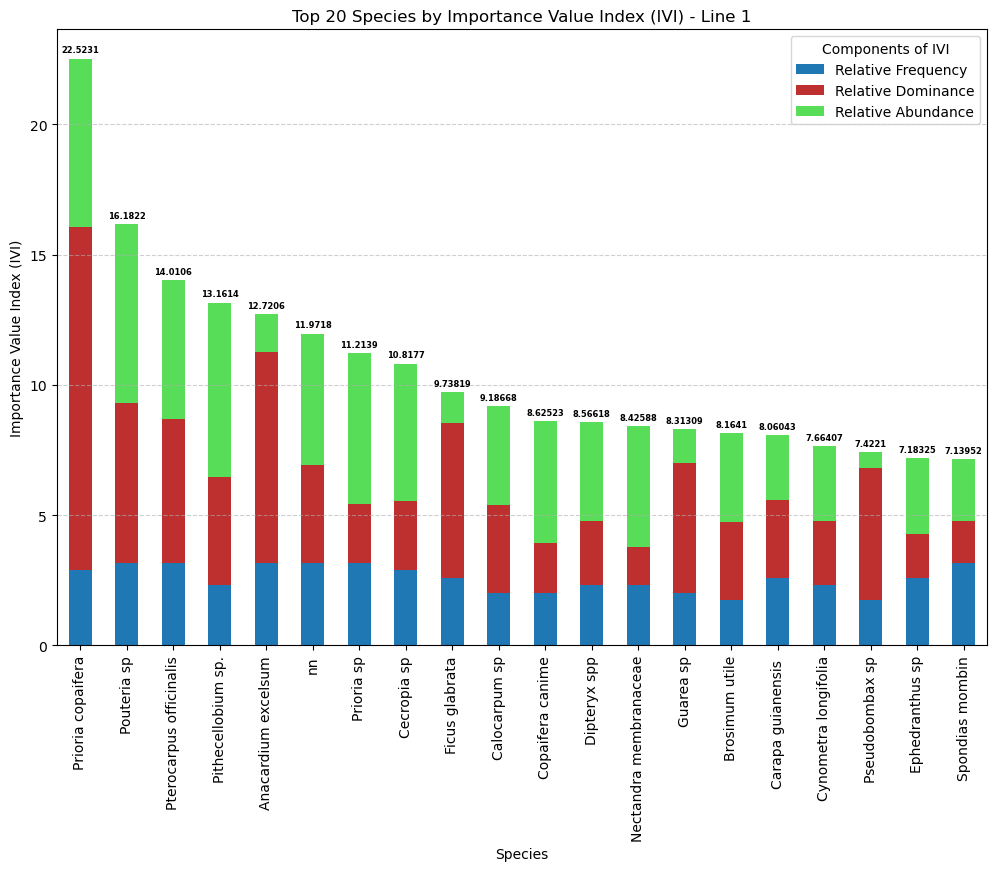

In [31]:
#Let's plot the top 20 species by IVI
#In this case we need a stacked bar plot that combines the three components of IVI
plt.figure(figsize=(10,6))
ax = top20_ivi1[['Fr', 'Dr', 'Ab']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,8),
    color=[color_ivi['Fr'], color_ivi['Dr'], color_ivi['Ab']]
)
plt.xlabel('Species')
plt.ylabel('Importance Value Index (IVI)')
plt.title('Top 20 Species by Importance Value Index (IVI) - Line 1')
plt.legend(title='Components of IVI', loc='upper right', labels=[dict_ivi[color_ivi] for color_ivi in ['Fr', 'Dr', 'Ab']])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.bar_label(ax.containers[2], padding=3, fontsize=6, fontweight='bold')

For Line 1, the top 20 tree species' IVI values were plotted. Then, as forest managers can we decide which tree species could we prior for improving sustainable forest management systems in the forest ecosystem, but it is always importance to do a further botanical, ecological and silvicultural research for the tree species we choose and prioritise for our practices.

Let's build the IVI tab le for the other seven lines.

In [32]:
# Helper to compute IVI for a given line dataframe

def compute_ivi(line_df):
    # Frequency: number of unique plots per species, then relative frequency
    fr = line_df.pivot_table(index='Scientific name', values='Plot', aggfunc='nunique')
    fr = fr[fr['Plot'] > 0]
    pl = line_df['Plot'].nunique() if 'Plot' in line_df.columns else 0
    fr['Freq'] = (fr['Plot'] / pl) * 100 if pl > 0 else 0
    freq_sum = fr['Freq'].sum() if pl > 0 else 0
    fr['Fr'] = (fr['Freq'] / freq_sum) * 100 if freq_sum > 0 else 0

    # Dominance: sum basal area and compute relative dominance
    do = line_df.pivot_table(index='Scientific name', values='Basal area [m2]', aggfunc='sum')
    do = do[do['Basal area [m2]'] != 0]
    g = do['Basal area [m2]'].sum()
    do['Dr'] = (do['Basal area [m2]'] / g) * 100 if g > 0 else 0

    # Abundance: count individuals and compute relative abundance
    ab = line_df.groupby('Scientific name').size().to_frame(name='Abundance')
    ab = ab[ab['Abundance'] > 0]
    n = ab['Abundance'].sum()
    ab['Ab'] = (ab['Abundance'] / n) * 100 if n > 0 else 0

    # Join components and compute IVI
    ivi = fr.join(do).join(ab)
    for col in ['Fr', 'Dr', 'Ab']:
        if col in ivi.columns:
            ivi[col] = ivi[col].fillna(0)
        else:
            ivi[col] = 0

    ivi['IVI'] = ivi['Fr'] + ivi['Dr'] + ivi['Ab']
    return ivi.sort_values(by='IVI', ascending=False)

# Compute IVI for lines 1-7
ivi1 = compute_ivi(line1)
ivi2 = compute_ivi(line2)
ivi3 = compute_ivi(line3)
ivi4 = compute_ivi(line4)
ivi5 = compute_ivi(line5)
ivi6 = compute_ivi(line6)
ivi7 = compute_ivi(line7)

# Print quick checks
for i, ivi_df in enumerate([ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7], start=1):
    print(f"Line {i} - IVI sum: {ivi_df['IVI'].sum():.2f}")

# Show top 20 species by IVI for each line
print('\nTop species by IVI (Line 1):')
print(ivi1.head(20))
print('\nTop species by IVI (Line 2):')
print(ivi2.head(20))
print('\nTop species by IVI (Line 3):')
print(ivi3.head(20))
print('\nTop species by IVI (Line 4):')
print(ivi4.head(20))
print('\nTop species by IVI (Line 5):')
print(ivi5.head(20))
print('\nTop species by IVI (Line 6):')
print(ivi6.head(20))
print('\nTop species by IVI (Line 7):')
print(ivi7.head(20))

C:\Users\migue\AppData\Local\Temp\ipykernel_21220\2827309685.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fr = line_df.pivot_table(index='Scientific name', values='Plot', aggfunc='nunique')
C:\Users\migue\AppData\Local\Temp\ipykernel_21220\2827309685.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  do = line_df.pivot_table(index='Scientific name', values='Basal area [m2]', aggfunc='sum')
C:\Users\migue\AppData\Local\Temp\ipykernel_21220\2827309685.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future 

Line 1 - IVI sum: 300.00
Line 2 - IVI sum: 300.00
Line 3 - IVI sum: 300.00
Line 4 - IVI sum: 300.00
Line 5 - IVI sum: 300.00
Line 6 - IVI sum: 300.00
Line 7 - IVI sum: 300.00

Top species by IVI (Line 1):
                         Plot       Freq        Fr  Basal area [m2]  \
Scientific name                                                       
Prioria copaifera          10  83.333333  2.890173        28.932947   
Pouteria sp                11  91.666667  3.179191        13.427027   
Pterocarpus officinalis    11  91.666667  3.179191        12.101714   
Pithecellobium sp.          8  66.666667  2.312139         9.112878   
Anacardium excelsum        11  91.666667  3.179191        17.725720   
nn                         11  91.666667  3.179191         8.249006   
Prioria sp                 11  91.666667  3.179191         4.913000   
Cecropia sp                10  83.333333  2.890173         5.826350   
Ficus glabrata              9  75.000000  2.601156        13.069839   
Calocarpum sp 

Here we could calculate and validate IVI values for the seven lines and ther is no error behind. However, we will reduce the species number to 15.

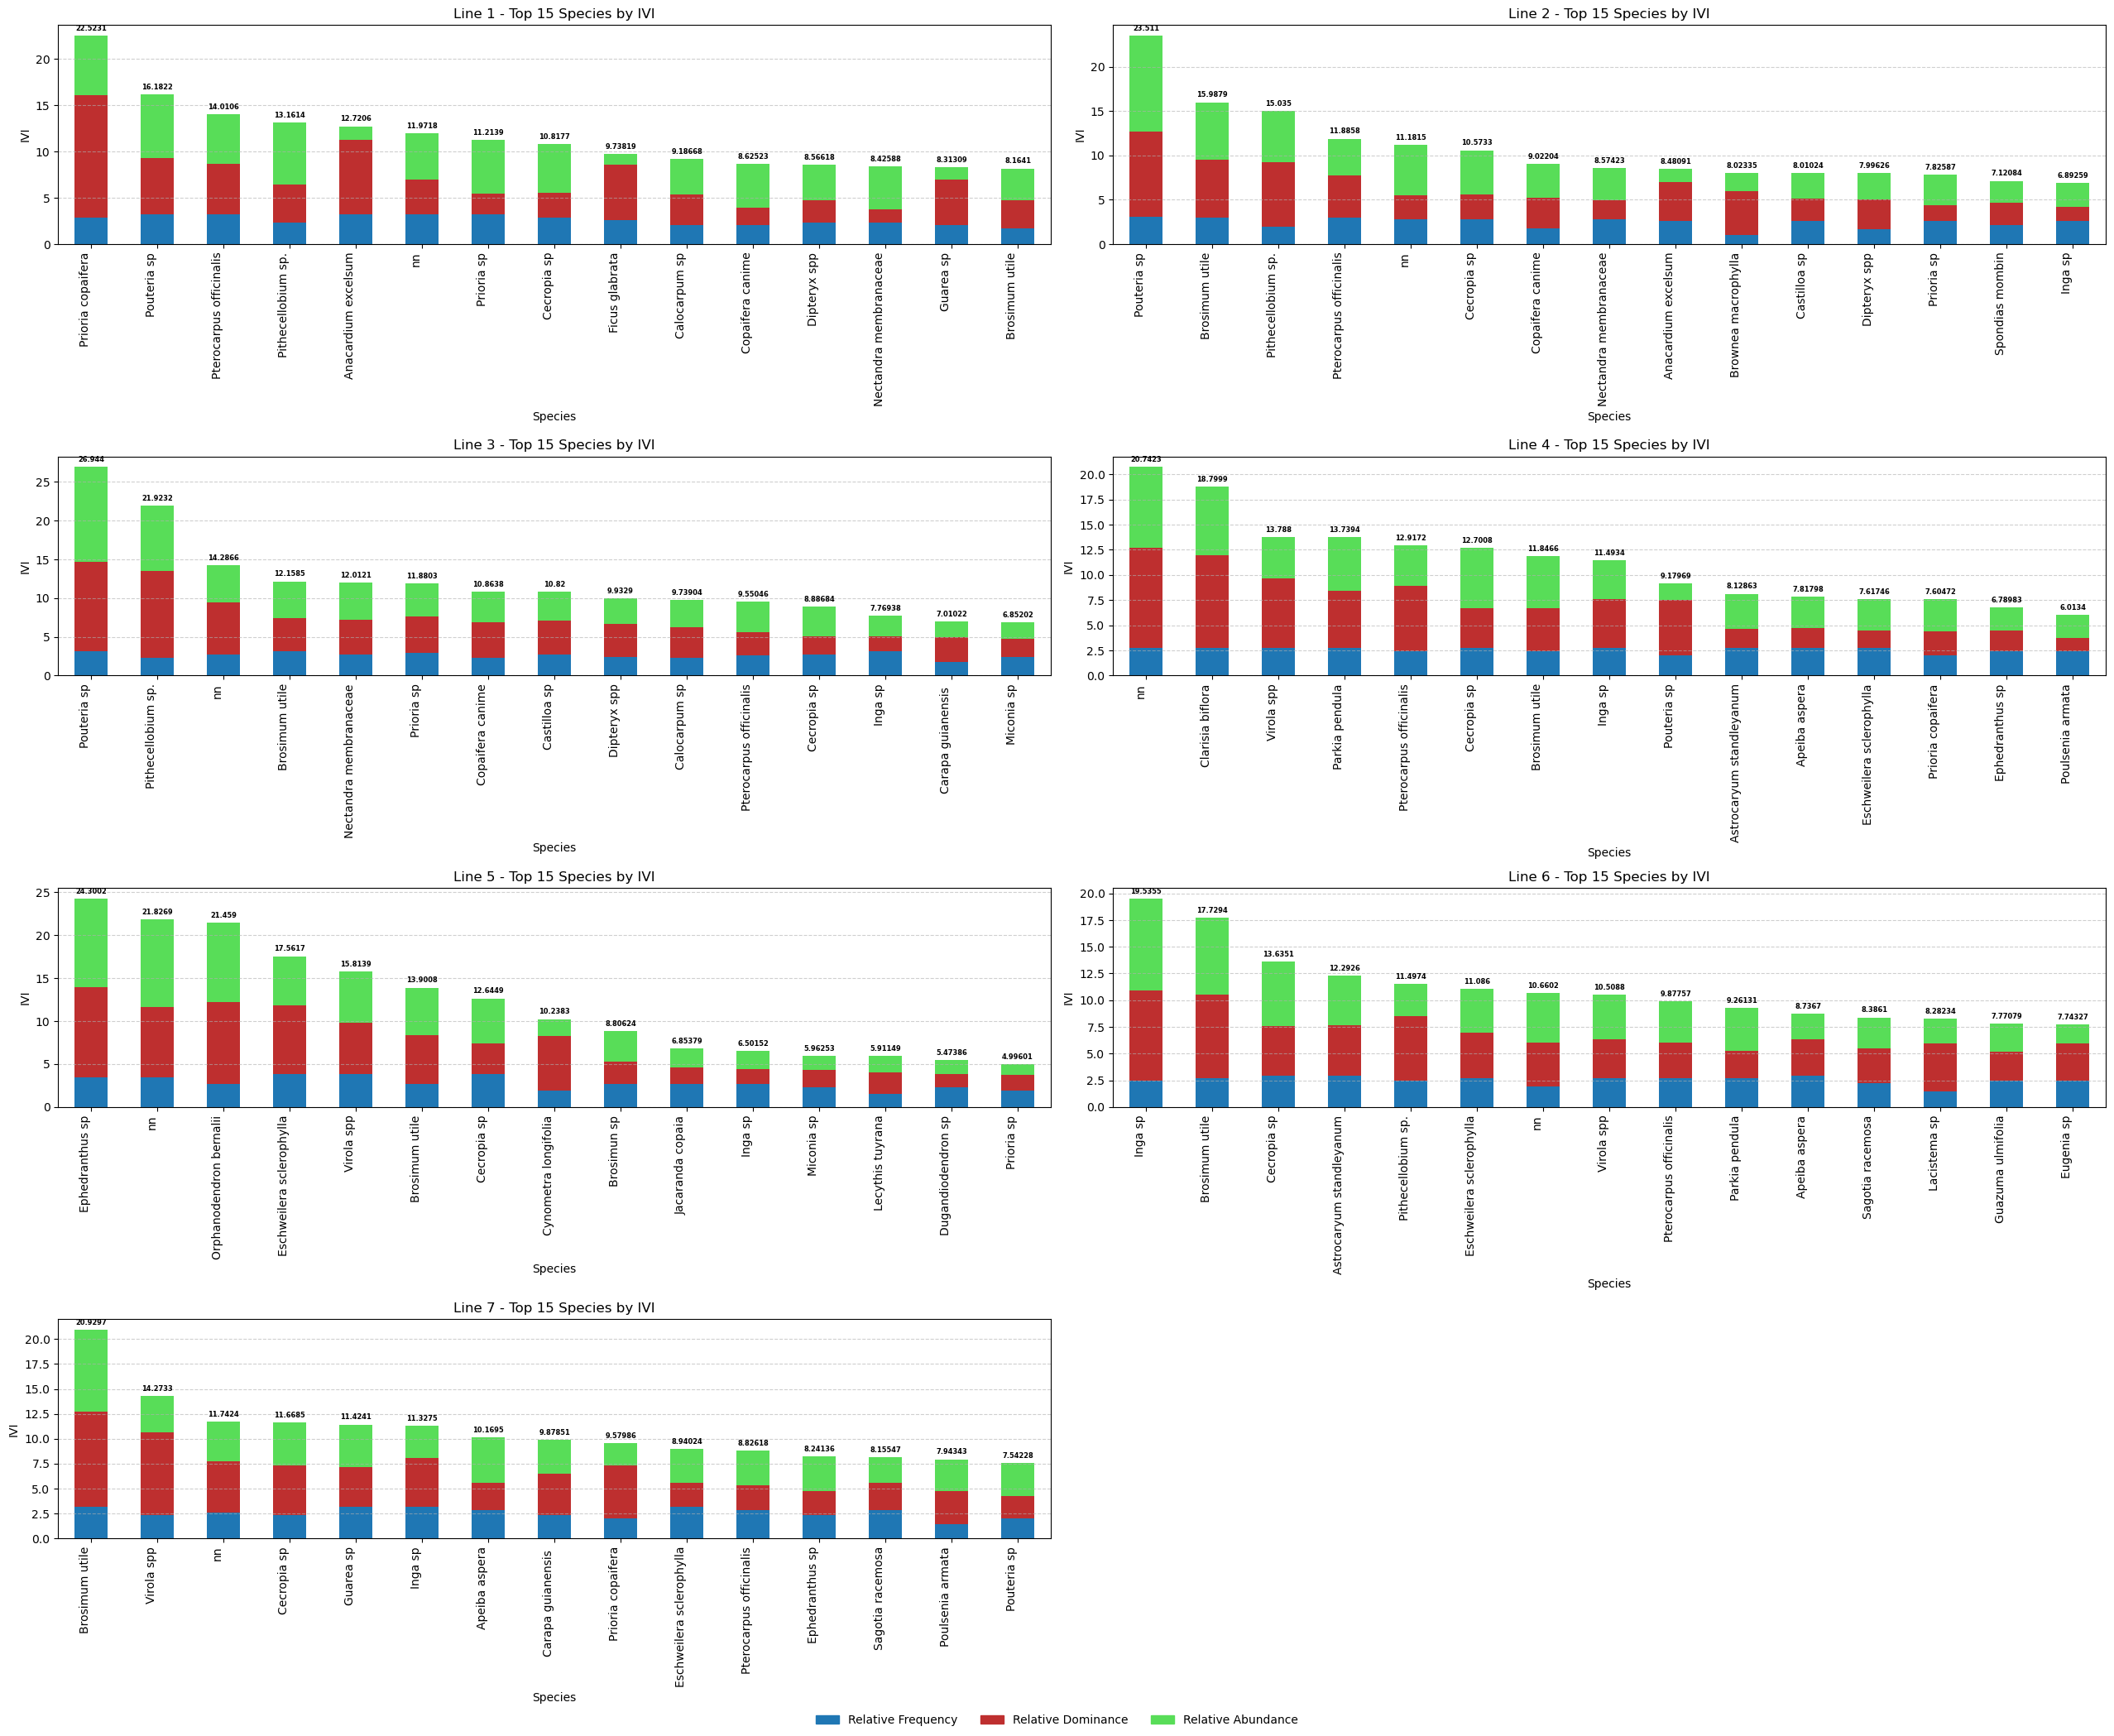

In [33]:
# Stacked IVI bar charts per line (4x2 matrix) — colors from color_ivi
top_n = 15
fig, axes = plt.subplots(4, 2, figsize=(27, 21))
axes = axes.flatten()

ivi_list = [ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7]
for i, ivi_df in enumerate(ivi_list):
    ax = axes[i]
    if ivi_df.empty:
        ax.set_visible(False)
        continue
    plot_df = ivi_df[["Fr", "Dr", "Ab"]].head(top_n)
    plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_ivi['Fr'], color_ivi['Dr'], color_ivi['Ab']], legend=False)
    ax.set_title(f'Line {i+1} - Top {min(top_n, len(plot_df))} Species by IVI')
    ax.set_xlabel('Species')
    ax.set_ylabel('IVI')
    ax.tick_params(axis='x', rotation=90)
    ax.set_xticklabels(plot_df.index, rotation=90, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Legend once on the last subplot column
handles = [plt.Rectangle((0,0),1,1, color=color_ivi[k]) for k in ['Fr','Dr','Ab']]
labels = [dict_ivi[k] for k in ['Fr','Dr','Ab']]
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

# Hide unused subplot (8th)
axes[7].set_visible(False)
plt.tight_layout(rect=[0,0.01,0.95,1])
for ax in axes:
    if ax.get_visible():
        ax.bar_label(ax.containers[2], padding=3, fontsize=6, fontweight='bold')
plt.show()

Let's reduce this number to 10.

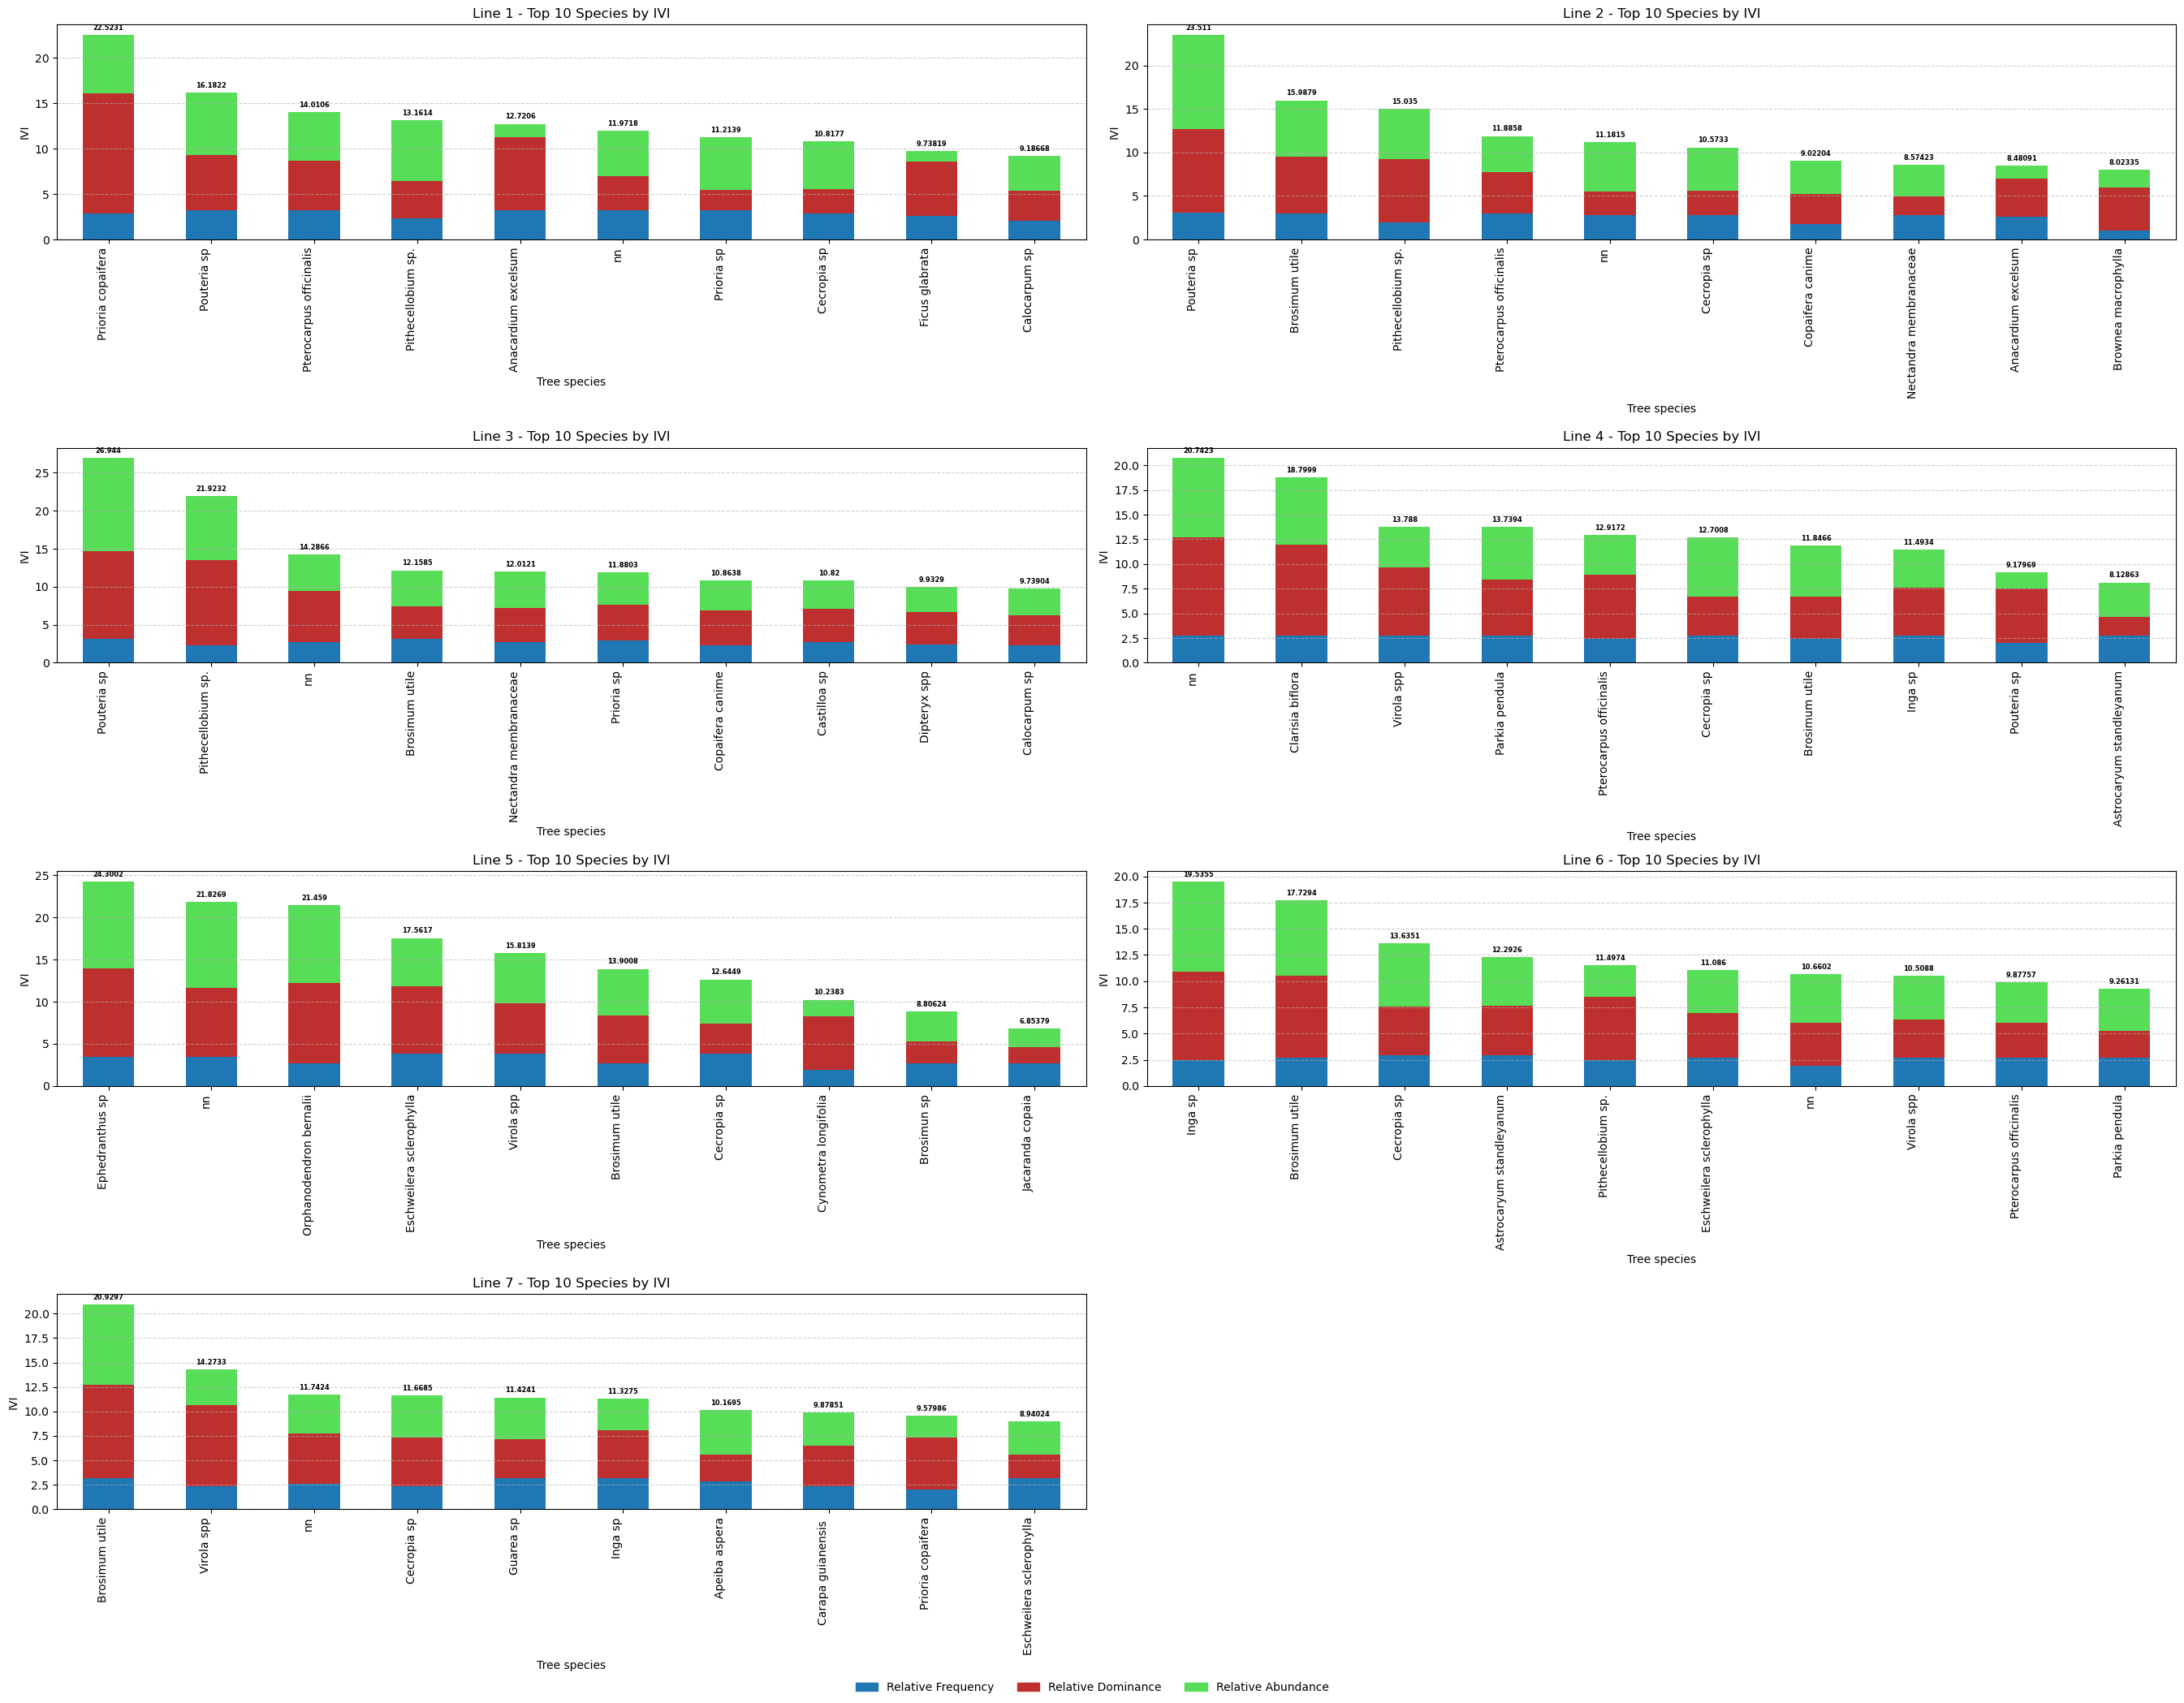

In [34]:
# Stacked IVI bar charts per line (4x2 matrix) — colors from color_ivi
top_n = 10
fig, axes = plt.subplots(4, 2, figsize=(27, 21))
axes = axes.flatten()

ivi_list = [ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7]
for i, ivi_df in enumerate(ivi_list):
    ax = axes[i]
    if ivi_df.empty:
        ax.set_visible(False)
        continue
    plot_df = ivi_df[["Fr", "Dr", "Ab"]].head(top_n)
    plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_ivi['Fr'], color_ivi['Dr'], color_ivi['Ab']], legend=False)
    ax.set_title(f'Line {i+1} - Top {min(top_n, len(plot_df))} Species by IVI')
    ax.set_xlabel('Tree species')
    ax.set_ylabel('IVI')
    ax.tick_params(axis='x', rotation=90)
    ax.set_xticklabels(plot_df.index, rotation=90, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Legend once on the last subplot column
handles = [plt.Rectangle((0,0),1,1, color=color_ivi[k]) for k in ['Fr','Dr','Ab']]
labels = [dict_ivi[k] for k in ['Fr','Dr','Ab']]
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

# Hide unused subplot (8th)
axes[7].set_visible(False)
plt.tight_layout(rect=[0,0.01,1,1])
for ax in axes:
    if ax.get_visible():
        ax.bar_label(ax.containers[2], padding=3, fontsize=6, fontweight='bold')
plt.show()

As observed in last chart, IVI values for the seven lines were calculated and this allowed us to established the ten most important tree species for each zone. Notice in charts and tables that an *nn* tree species figures  as one of the most important in the different lines. Why this could have happened? Well, it is propably that field measurers did not identify this individual trees when they measured them and they did not take any botanical sample which allowed to get a precise identification for this trees. Whay would you do as forest manager? Make your reflexions about this. In parallel, based on this analysis, which tree species would you prior for sustainable forest management and why?

## References

Curtis, J. T., & McIntosh, R. P. (1951). An upland forest continuum in the prairie‐Forest Border Region of Wisconsin. *Ecology, 32*(3), 476–496. [doi:10.2307/1931725](https://esajournals.onlinelibrary.wiley.com/doi/10.2307/1931725)

Lamprecht, H. (1990). *Silvicultura en los trópicos: Los ecosistemas forestales y sus especies arbóreas; posibilidades y métodos para un aprovechamiento sostenido*. Deutsche Gesellschaft für Zusammenarbeit (GTZ) GmbH. Rosdorf: TZ-Verl.-Ges. ISBN: 3-88085-440-8.

Melo-Cruz, O. A., & Vargas-Ríos, R. (2003). *Evaluación ecológica y silvicultural de ecosistemas boscosos*. Ibagué: Universidad del Tolima. ISBN: 956-9243-03-07

Raunkiær, C. (1934). *The life forms of plants and statistical plant geography*. Oxford University Press.